# Week 8 — Dynamic Factor Models

When we have many time series (GDP, employment, industrial production, …), a small number of common **factors** may drive them all. Dynamic factor models extract these latent factors.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 8.1 The Idea: Dimension Reduction for Time Series

$$y_{it} = \lambda_i' f_t + e_{it}$$

where $f_t$ is a $k$-dimensional vector of factors and $\lambda_i$ are loadings.

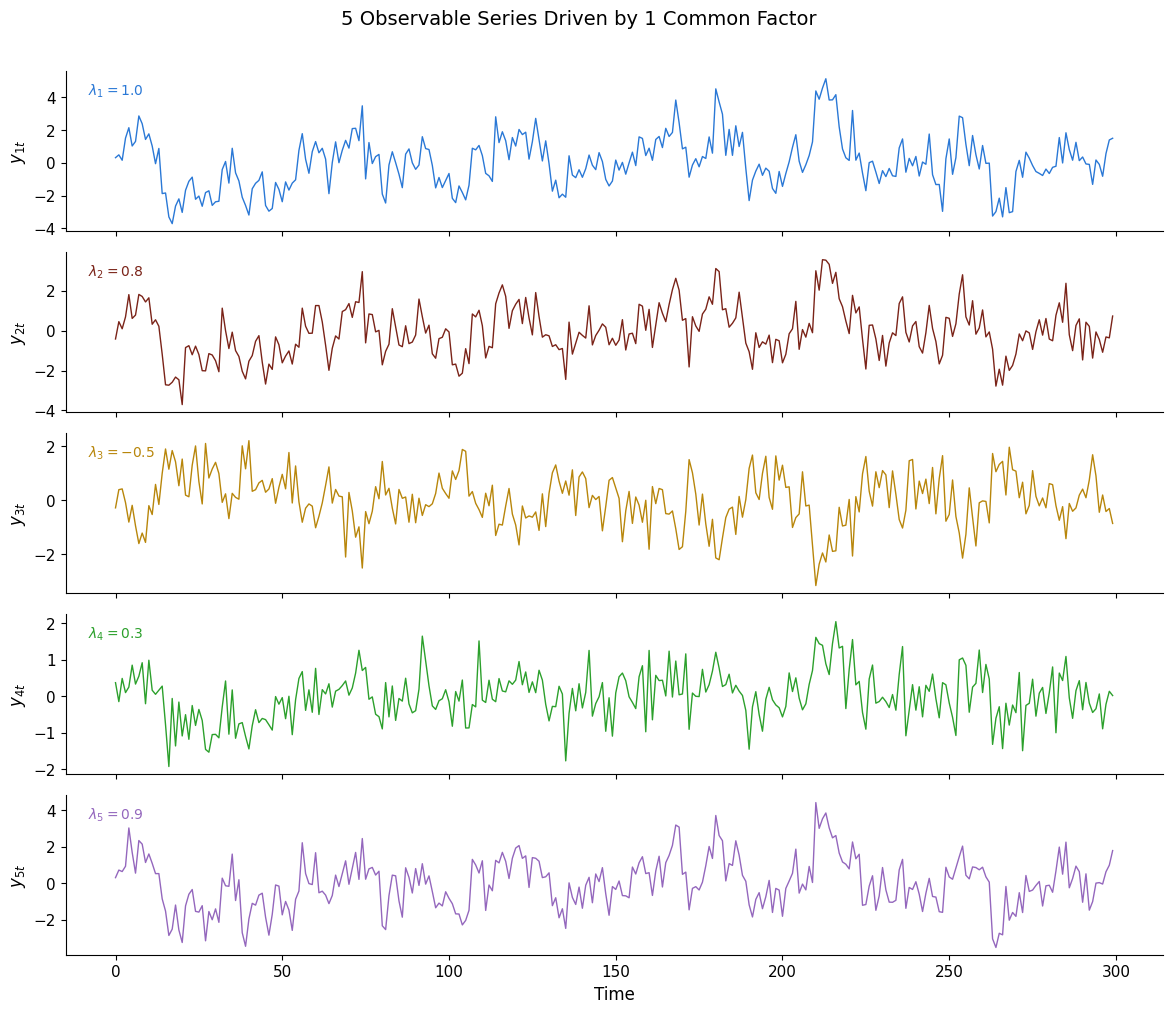

In [2]:
# Simulate a dynamic factor model: 1 factor driving 5 series
np.random.seed(42)
T = 300
k = 1  # number of factors

# Factor follows AR(1)
factor = np.zeros(T)
for t in range(1, T):
    factor[t] = 0.8 * factor[t-1] + np.random.normal(0, 1)

# Loadings and idiosyncratic errors
n_series = 5
loadings = np.array([1.0, 0.8, -0.5, 0.3, 0.9])
Y = np.outer(factor, loadings) + np.random.normal(0, 0.5, (T, n_series))

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
colours = [UOE_BLUE, UOE_RED, UOE_GOLD, '#2ca02c', '#9467bd']
for i, (ax, col) in enumerate(zip(axes, colours)):
    ax.plot(Y[:, i], color=col, lw=1)
    ax.set_ylabel(f'$y_{{{i+1}t}}$')
    ax.text(0.02, 0.85, f'$\\lambda_{i+1} = {loadings[i]}$',
            transform=ax.transAxes, fontsize=10, color=col)
axes[-1].set_xlabel('Time')
plt.suptitle('5 Observable Series Driven by 1 Common Factor', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8.2 Extracting Factors with PCA

Correlation between true factor and PC1: 0.9712


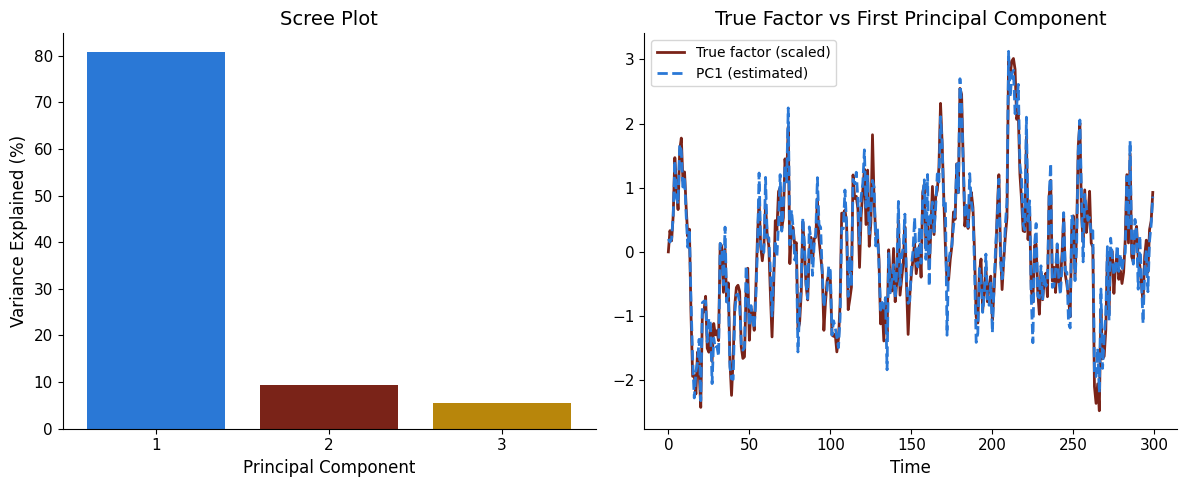

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardise
scaler = StandardScaler()
Y_std = scaler.fit_transform(Y)

pca = PCA(n_components=3)
pca.fit(Y_std)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
ax1.bar(range(1, 4), pca.explained_variance_ratio_ * 100,
        color=[UOE_BLUE, UOE_RED, UOE_GOLD])
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Scree Plot')
ax1.set_xticks([1, 2, 3])

# Compare extracted factor vs true factor
pc1 = pca.transform(Y_std)[:, 0]
# Align sign
if np.corrcoef(pc1, factor)[0, 1] < 0:
    pc1 = -pc1

ax2.plot(factor / np.std(factor), color=UOE_RED, lw=2, label='True factor (scaled)')
ax2.plot(pc1 / np.std(pc1), '--', color=UOE_BLUE, lw=2, label='PC1 (estimated)')
ax2.set_xlabel('Time')
ax2.set_title('True Factor vs First Principal Component')
ax2.legend()

corr = np.corrcoef(pc1, factor)[0, 1]
print(f"Correlation between true factor and PC1: {corr:.4f}")

plt.tight_layout()
plt.show()


## 8.3 Estimating a Dynamic Factor Model with `statsmodels`

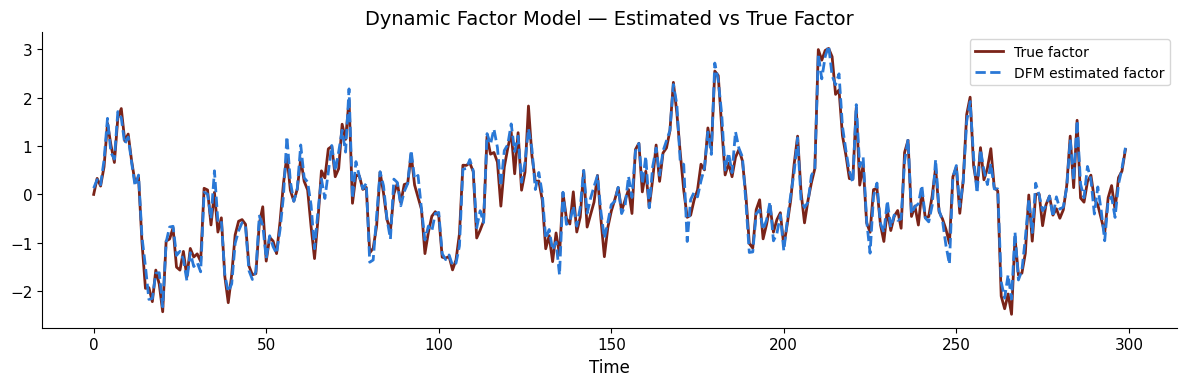

In [4]:
import statsmodels.api as sm
import pandas as pd

import pandas as pd
df_fac = pd.DataFrame(Y_std, columns=[f'Series_{i+1}' for i in range(5)])

mod_dfm = sm.tsa.DynamicFactor(df_fac, k_factors=1, factor_order=1)
res_dfm = mod_dfm.fit(disp=False, maxiter=500)

estimated_factor = res_dfm.factors.filtered[0]
if np.corrcoef(estimated_factor, factor)[0, 1] < 0:
    estimated_factor = -estimated_factor

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(factor / np.std(factor), color=UOE_RED, lw=2, label='True factor')
ax.plot(estimated_factor / np.std(estimated_factor), '--',
        color=UOE_BLUE, lw=2, label='DFM estimated factor')
ax.set_title('Dynamic Factor Model — Estimated vs True Factor')
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()


## 8.4 Factor Loadings

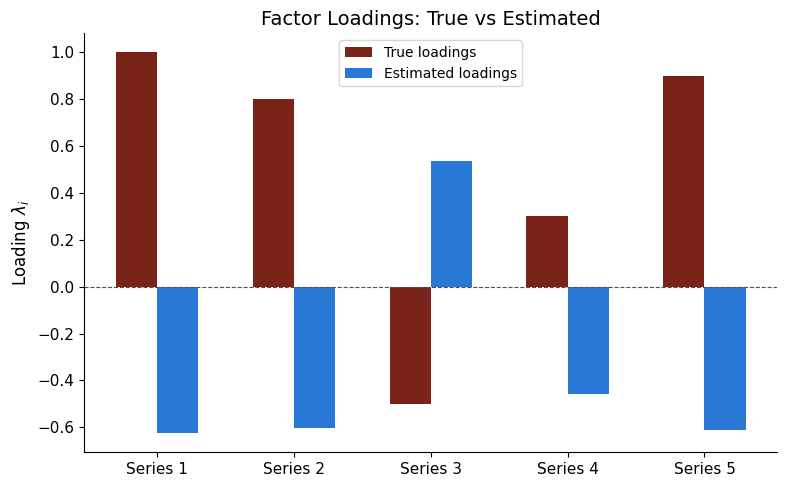

In [5]:
est_loadings = res_dfm.params[:5]

fig, ax = plt.subplots(figsize=(8, 5))
x = range(5)
ax.bar([i - 0.15 for i in x], loadings, width=0.3, color=UOE_RED, label='True loadings')
ax.bar([i + 0.15 for i in x], est_loadings, width=0.3, color=UOE_BLUE, label='Estimated loadings')
ax.set_xticks(list(x))
ax.set_xticklabels([f'Series {i+1}' for i in range(5)])
ax.set_ylabel('Loading $\\lambda_i$')
ax.set_title('Factor Loadings: True vs Estimated')
ax.legend()
ax.axhline(0, ls='--', color=UOE_GREY, lw=0.8)
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Simulate a model with 2 factors and 8 series, then estimate with PCA.</summary>

```python
np.random.seed(0)
T, n = 300, 8
F = np.zeros((T, 2))
for t in range(1, T):
    F[t] = 0.7 * F[t-1] + np.random.normal(0, 1, 2)
L = np.random.randn(n, 2)
Y = F @ L.T + np.random.normal(0, 0.5, (T, n))
pca = PCA(n_components=4).fit(StandardScaler().fit_transform(Y))
plt.bar(range(1,5), pca.explained_variance_ratio_*100)
plt.title('Scree Plot — 2 true factors')
plt.show()
```
</details>